In [155]:
import matplotlib.pyplot as plt
import pandas as pd

In [156]:
file = '../data/outs/all_1_copy.csv'

try:
    df = pd.read_csv(file, sep=' ')
    print("Dados lidos com sucesso!")

except FileNotFoundError:
    print(f"Erro: Arquivo '{file}' não encontrado!")

Erro: Arquivo '../data/outs/all_1_copy.csv' não encontrado!


In [157]:
df.dtypes

nome       object
n           int64
m           int64
c           int64
fila       object
run         int64
l1          int64
l2          int64
llc         int64
cycles      int64
inst        int64
l1_mr     float64
l2_mr     float64
llc_mr    float64
dtype: object

In [158]:
df.head()

,nome,n,m,c,fila,run,l1,l2,llc,cycles,inst,l1_mr,l2_mr,llc_mr
0,NY,264346,733846,36946,2LVBQDK,71,0,0,0,0,0,NaN,NaN,NaN
1,NY,264346,733846,36946,2LVBQDK,71,0,0,0,0,0,NaN,NaN,NaN
2,NY,264346,733846,36946,2LVBQDK,70,0,0,0,0,0,NaN,NaN,NaN
3,NY,264346,733846,36946,2LVBQDK,70,0,0,0,0,0,NaN,NaN,NaN
4,NY,264346,733846,36946,2LVBQDK,70,0,0,0,0,0,NaN,NaN,NaN


## Tempo de execução por quantidade de vértices

In [167]:
df_run_n = (
    df.groupby(['nome', 'fila'])['run']
      .agg(['mean', 'std', 'var'])
      .reset_index()
)
df_run_n

,nome,fila,mean,std,var
0,BAY,1LVBQ,102.8,1.135292,1.288889
1,BAY,2LVBQ,76.4,0.699206,0.488889
2,BAY,2LVBQDK,85.0,4.666667,21.777778
3,BAY,BINH,129.3,1.159502,1.344444
4,BAY,FIB,222.4,1.349897,1.822222
5,CAL,1LVBQ,617.5,3.689324,13.611111
6,CAL,2LVBQ,485.7,3.368151,11.344444
7,CAL,2LVBQDK,526.0,3.858612,14.888889
8,CAL,BINH,812.8,3.119829,9.733333
9,CAL,FIB,1416.2,11.707547,137.066667


In [165]:
df_run_n = df_run_n[df_run_n['fila'].isin(["BINH", "2LVBQDK"])]
df_run_n

,nome,fila,n,m,c,mean,std,var
2,BAY,2LVBQDK,321270,800172,94305,85.0,4.666667,21.777778
3,BAY,BINH,321270,800172,94305,129.3,1.159502,1.344444
7,CAL,2LVBQDK,1890815,4657742,215354,526.0,3.858612,14.888889
8,CAL,BINH,1890815,4657742,215354,812.8,3.119829,9.733333
12,COL,2LVBQDK,435666,1057066,137384,115.6,1.264911,1.600000
13,COL,BINH,435666,1057066,137384,174.2,0.788811,0.622222
17,CTR,2LVBQDK,14081816,34292496,214013,5510.6,6.363088,40.488889
18,CTR,BINH,14081816,34292496,214013,8106.5,236.186955,55784.277778
22,E,2LVBQDK,3598623,8778114,200760,1024.6,0.966092,0.933333
23,E,BINH,3598623,8778114,200760,1661.3,4.056545,16.455556


In [161]:
df_pivot = df_run_n.pivot_table(
    index=['nome', 'n', 'm', 'c'],          # linhas (ex: BAY, CAL, COL...)
    columns=['fila'],        # vira colunas (BINH, 2LVBQDK)
    values=['mean', 'std'] # valores que você quer
)

df_pivot

mean                 std            
fila                          2LVBQDK     BINH    2LVBQDK        BINH
nome n        m        c                                             
BAY  321270   800172   94305     85.0    129.3   4.666667    1.159502
CAL  1890815  4657742  215354   526.0    812.8   3.858612    3.119829
COL  435666   1057066  137384   115.6    174.2   1.264911    0.788811
CTR  14081816 34292496 214013  5510.6   8106.5   6.363088  236.186955
E    3598623  8778114  200760  1024.6   1661.3   0.966092    4.056545
FLA  1070376  2712798  214013   284.6    436.8   0.699206    1.751190
LKS  2758119  6885658  138911   762.3   1198.0   3.945462    2.624669
NE   1524453  3897636  63247    436.4    723.5   0.699206    1.649916
NW   1207945  2840208  128569   321.6    497.4   0.516398    1.074968
NY   264346   733846   36946     70.0    111.2   0.666667    0.421637
USA  23947347 58333344 368855  7918.2  12575.0  32.406447    6.018490
W    6262104  15248146 368855  1854.0   3017.5   2.494438    5.296750

In [162]:
import math, numpy as np

df_pivot = df_pivot.reset_index()
df_pivot['sqrt_c'] = df_pivot['c'].apply(math.sqrt)
df_pivot['log_n'] = df_pivot['n'].apply(math.log2)

# Razões — "quantas vezes maior"
df_pivot['sqrt_vs_log_ratio'] = df_pivot['sqrt_c'] / df_pivot['log_n']
df_pivot

nome         n         m       c    mean                 std              \
fila                                  2LVBQDK     BINH    2LVBQDK        BINH   
0     BAY    321270    800172   94305    85.0    129.3   4.666667    1.159502   
1     CAL   1890815   4657742  215354   526.0    812.8   3.858612    3.119829   
2     COL    435666   1057066  137384   115.6    174.2   1.264911    0.788811   
3     CTR  14081816  34292496  214013  5510.6   8106.5   6.363088  236.186955   
4       E   3598623   8778114  200760  1024.6   1661.3   0.966092    4.056545   
5     FLA   1070376   2712798  214013   284.6    436.8   0.699206    1.751190   
6     LKS   2758119   6885658  138911   762.3   1198.0   3.945462    2.624669   
7      NE   1524453   3897636   63247   436.4    723.5   0.699206    1.649916   
8      NW   1207945   2840208  128569   321.6    497.4   0.516398    1.074968   
9      NY    264346    733846   36946    70.0    111.2   0.666667    0.421637   
10    USA  23947347  58333344  368855  7918.2  12575.0  32.406447    6.018490   
11      W   6262104  15248146  368855  1854.0   3017.5   2.494438    5.296750   

          sqrt_c      log_n sqrt_vs_log_ratio  
fila                                           
0     307.091192  18.293427         16.786969  
1     464.062496  20.850577         22.256578  
2     370.653477  18.732863         19.786270  
3     462.615391  23.747330         19.480733  
4     448.062496  21.779014         20.573131  
5     462.615391  20.029686         23.096487  
6     372.707660  21.395253         17.420110  
7     251.489562  20.539860         12.243976  
8     358.565196  20.204123         17.747130  
9     192.213423  18.012068         10.671369  
10    607.334340  24.513363         24.775644  
11    607.334340  22.578216         26.899129

In [163]:
latex = df_data.to_latex(
    index=False,
    column_format="|lrrrrrrr|",
    caption="Características dos grafos e tempo de execução do Dijkstra...",
    label="tab:res",
    float_format="%.1f"
)

print(latex)

\begin{table}
\caption{Características dos grafos e tempo de execução do Dijkstra...}
\label{tab:res}
\begin{tabular}{|lrrrrrrr|}
\toprule
nome & n & m & c & fila & sqrt_c & log_n & sqrt_vs_log_ratio \\
\midrule
BAY & 321270 & 800172 & 94305 & 2LVBQDK & 307.1 & 18.3 & 16.8 \\
CAL & 1890815 & 4657742 & 215354 & 2LVBQDK & 464.1 & 20.9 & 22.3 \\
COL & 435666 & 1057066 & 137384 & 2LVBQDK & 370.7 & 18.7 & 19.8 \\
CTR & 14081816 & 34292496 & 214013 & 2LVBQDK & 462.6 & 23.7 & 19.5 \\
E & 3598623 & 8778114 & 200760 & 2LVBQDK & 448.1 & 21.8 & 20.6 \\
FLA & 1070376 & 2712798 & 214013 & 2LVBQDK & 462.6 & 20.0 & 23.1 \\
LKS & 2758119 & 6885658 & 138911 & 2LVBQDK & 372.7 & 21.4 & 17.4 \\
NE & 1524453 & 3897636 & 63247 & 2LVBQDK & 251.5 & 20.5 & 12.2 \\
NW & 1207945 & 2840208 & 128569 & 2LVBQDK & 358.6 & 20.2 & 17.7 \\
NY & 264346 & 733846 & 36946 & 2LVBQDK & 192.2 & 18.0 & 10.7 \\
USA & 23947347 & 58333344 & 368855 & 2LVBQDK & 607.3 & 24.5 & 24.8 \\
W & 6262104 & 15248146 & 368855 & 2LVBQDK & 607.3

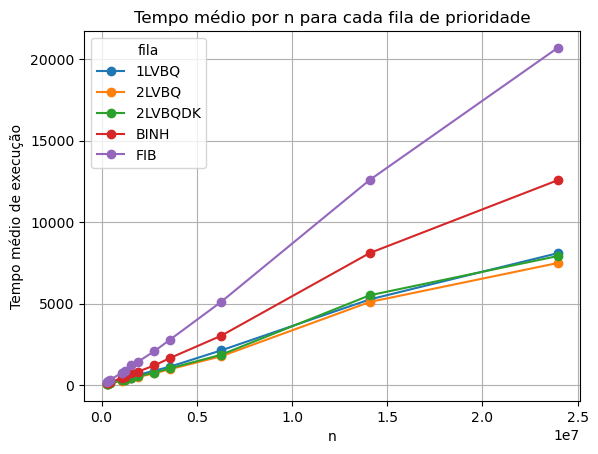

ModuleNotFoundError: No module named 'tikzplotlib'

In [164]:
pivot = df.groupby(['n','fila'])['run'].mean().unstack()

pivot.plot(marker='o')
plt.xlabel('n')
plt.ylabel('Tempo médio de execução')
plt.title('Tempo médio por n para cada fila de prioridade')
plt.grid(True)
plt.savefig('run_n.png', dpi=300, bbox_inches='tight')
plt.show()
import matplotlib.pyplot as plt
import tikzplotlib

tikzplotlib.save("grafico.tex")

In [ ]:
import matplotlib.pyplot as plt
import tikzplotlib

tikzplotlib.save("grafico.tex")

ModuleNotFoundError: No module named 'tikzplotlib'

## Correlação entre métricas e tempo de execução

In [ ]:
df['l1_mr'] = df['l1'] / df['cycles']
df['l2_mr'] = df['l2'] / df['cycles']
df['llc_mr'] = df['llc'] / df['cycles']

In [ ]:
df_run_miss = (
    df.groupby(['nome','fila'])[['run','l1','l2','llc','cycles', 'inst', 'l1_mr', 'l2_mr', 'llc_mr']]
      .mean()
      .reset_index()
)

In [ ]:
df_run_miss.head()

,nome,fila,run,l1,l2,llc,cycles,inst,l1_mr,l2_mr,llc_mr
0,BAY,1LVBQ,102.8,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,BAY,2LVBQ,76.4,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,BAY,2LVBQDK,85.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
3,BAY,BINH,129.3,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,BAY,FIB,222.4,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
